In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Movie–User interaction matrix X
# Rows: movies 1–9
# Columns: users 1–11
# 1 = checkmark (user likes movie), 0 = no interaction

X = np.array([
    # u1 u2 u3 u4 u5 u6 u7 u8 u9 u10 u11
    [ 0,  0,  0,  0,  1,  1,  1,  0,  0,  0,  0],  # movie 1
    [ 1,  0,  1,  1,  0,  0,  0,  0,  0,  0,  0],  # movie 2
    [ 0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  1],  # movie 3
    [ 0,  1,  0,  1,  0,  0,  0,  0,  0,  0,  0],  # movie 4
    [ 0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0],  # movie 5
    [ 0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  0],  # movie 6
    [ 0,  0,  0,  0,  1,  1,  0,  0,  0,  0,  0],  # movie 7
    [ 0,  0,  0,  0,  0,  0,  0,  1,  0,  1,  1],  # movie 8
    [ 1,  1,  1,  1,  0,  0,  0,  0,  0,  0,  0],  # movie 9
])

print("Shape of X:", X.shape)
print(X)

Shape of X: (9, 11)
[[0 0 0 0 1 1 1 0 0 0 0]
 [1 0 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 1]
 [0 1 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 1 0]
 [0 0 0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 1 1]
 [1 1 1 1 0 0 0 0 0 0 0]]


In [91]:

def rmr_factorization(X,k, num_iters=50):
    m, n = X.shape

    C = np.random.rand(m, k)
    P = np.random.rand(n, k)

    for _ in range(num_iters):
        C = X @ P @ np.linalg.inv(P.T @ P)
        P = X.T @ C @ np.linalg.inv(C.T @ C)

        X_hat = C @ P.T
        error = np.sum((X - X_hat) ** 2)

    return C, P, error

#######################################################
def rmr_plot(X,k_values):

    errors = []

    for k in k_values:

       C, P,error = rmr_factorization(X,k,num_iters=50)
       errors.append(error)

       print(f"k = {k}, reconstruction error = {error:.4f}")


      # Plot reconstruction error vs k
    plt.figure()
    plt.plot(k_values, errors, marker='o')
    plt.xlabel("Latent dimension k")
    plt.ylabel("Reconstruction error")
    plt.title("Reconstruction Error vs Latent Dimension k")
    plt.grid(True)
    plt.show()

    return errors

k = 1, reconstruction error = 15.5812
k = 2, reconstruction error = 10.0196
k = 3, reconstruction error = 4.9707
k = 4, reconstruction error = 3.5341


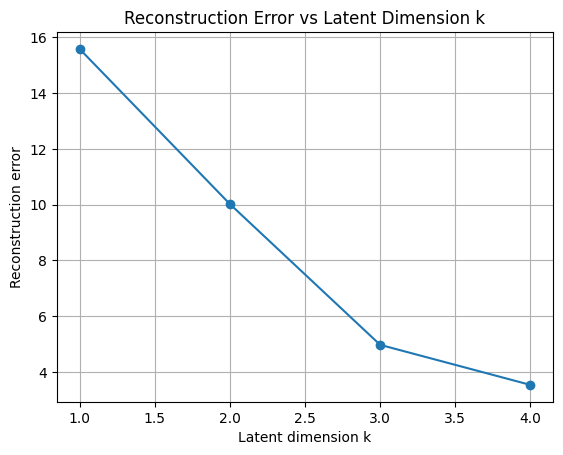

[np.float64(15.58116732403023),
 np.float64(10.01961924813034),
 np.float64(4.970697171698822),
 np.float64(3.534080332565669)]

In [92]:
k_values = [1, 2, 3, 4]
rmr_plot(X,k_values)


What happens to the reconstruction
quality as k increases?:

As k increases, the reconstruction error decreases as we can see from the plot

In [ ]:
def batch_gradient_descent_mf(X, C_init, P_init, learning_rate=0.01, n_iterations=100):
    C = C_init.copy()
    P = P_init.copy()

    # Store history for visualization (optional)
    loss_history = []

    #
    for i in range(n_iterations):
        # 1. Calculate the Error Matrix E (N x M)
        # E = X - C @ P.T
        # Note: P^T in the math is P.T in numpy
        E = X - C @ P.T

        # 2. Derive Gradients (Task 1)
        # Gradient w.r.t C (N x K)
        # ∇_C L = -2 * E @ P
        grad_C = -2 * E @ P

        # Gradient w.r.t P (M x K)
        # ∇_P L = -2 * E.T @ C
        grad_P = -2 * E.T @ C

        # 3. Implement Gradient Descent Updates (Task 2 & 3)
        # C_new = C_old - eta * ∇_C L
        C = C - learning_rate * grad_C

        # P_new = P_old - eta * ∇_P L
        P = P - learning_rate * grad_P

        # Calculate Loss (optional: to monitor convergence)
        loss = np.sum((E) ** 2)
        loss_history.append(loss)

        if (i + 1) % 10 == 0:
            print(f"Iteration {i+1}/{n_iterations} | Loss: {loss:.4f}")

    return C, P, loss_history

why a learning rate is necessary in gradient descent.
A learning rate is necessary because the gradient only gives the direction of descent, not the step size.
The learning rate controls how far the parameters are updated, preventing overshooting when it is too large and slow convergence when it is too small.

Iteration 10/300 | Loss: 38.5573
Iteration 20/300 | Loss: 38.3794
Iteration 30/300 | Loss: 38.2030
Iteration 40/300 | Loss: 38.0280
Iteration 50/300 | Loss: 37.8545
Iteration 60/300 | Loss: 37.6823
Iteration 70/300 | Loss: 37.5115
Iteration 80/300 | Loss: 37.3420
Iteration 90/300 | Loss: 37.1739
Iteration 100/300 | Loss: 37.0072
Iteration 110/300 | Loss: 36.8417
Iteration 120/300 | Loss: 36.6776
Iteration 130/300 | Loss: 36.5147
Iteration 140/300 | Loss: 36.3532
Iteration 150/300 | Loss: 36.1928
Iteration 160/300 | Loss: 36.0338
Iteration 170/300 | Loss: 35.8759
Iteration 180/300 | Loss: 35.7193
Iteration 190/300 | Loss: 35.5639
Iteration 200/300 | Loss: 35.4097
Iteration 210/300 | Loss: 35.2567
Iteration 220/300 | Loss: 35.1049
Iteration 230/300 | Loss: 34.9542
Iteration 240/300 | Loss: 34.8047
Iteration 250/300 | Loss: 34.6563
Iteration 260/300 | Loss: 34.5090
Iteration 270/300 | Loss: 34.3628
Iteration 280/300 | Loss: 34.2177
Iteration 290/300 | Loss: 34.0738
Iteration 300/300 | Los

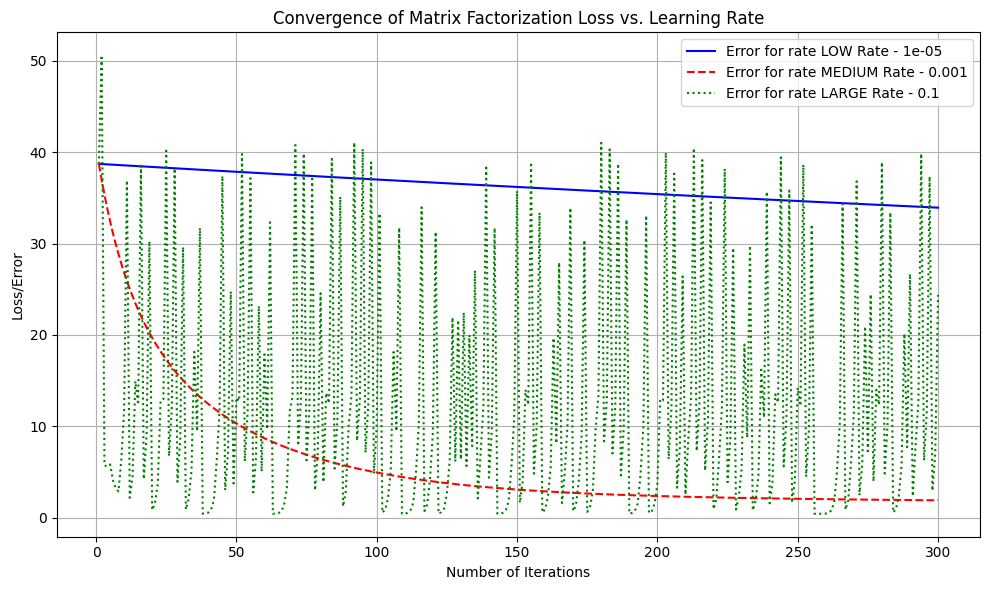

In [ ]:
import matplotlib.pyplot as plt

# Testing with multiple learning rates

LOW_RATE = 0.00001
MEDIUM_RATE = 0.001
LARGE_RATE = 0.1

N_ITERATIONS = 700
rates = [LOW_RATE, MEDIUM_RATE, LARGE_RATE]
# Change errors to a list of lists to store histories separately
all_histories = []

# LEARNING_RATE = 0.01
# N_ITERATIONS = 700


# Setup parameters
# 1. Generate a synthetic matrix X
np.random.seed(42)
N = 9 # Define N for X.shape
M = 11 # Define M for X.shape
K = 3       # Latent dimension

C_true = np.random.rand(N, K)
P_true = np.random.rand(M, K)
X = C_true @ P_true.T + np.random.normal(0, 0.1, (N, M)) # X = C*P.T + noise

# 2. Initialize C and P randomly
C0 = np.random.rand(N, K)
P0 = np.random.rand(M, K)


for rate in rates:
    # C0.copy() and P0.copy() are used to ensure each run starts from the same initial state
    C_final, P_final, history = batch_gradient_descent_mf(
    X, C0.copy(), P0.copy(), learning_rate=rate, n_iterations=N_ITERATIONS
    )

    # Change to append the whole history list
    all_histories.append(history)

    print(f"\nFactorization Complete. for rate - {rate}")
    print(f"Final Loss: {history[-1]:.4f}")


# 3. Create the Plot
plt.figure(figsize=(10, 6))

# CRITICAL FIX: The X-axis should be the iteration number (1 to N_ITERATIONS),
# and the Y-axis should be the loss/error. The original code had them swapped.
x_axis =  list(range(1, N_ITERATIONS + 1))


# Plot the first line
# CRITICAL FIX: Access the history from the all_histories list and swap axes
plt.plot(x_axis, all_histories[0], label=f'Error for rate LOW Rate - {LOW_RATE}', color='blue', linestyle='-')

# Plot the second line
# CRITICAL FIX: Access the history from the all_histories list and swap axes
plt.plot(x_axis, all_histories[1], label=f'Error for rate MEDIUM Rate - {MEDIUM_RATE}', color='red', linestyle='--')

# Plot the third line
# CRITICAL FIX: Access the history from the all_histories list and swap axes
plt.plot(x_axis, all_histories[2], label=f'Error for rate LARGE Rate - {LARGE_RATE}', color='green', linestyle=':') # Changed to ':' for better differentiation

# 4. Add Labels and Legend
plt.title('Convergence of Matrix Factorization Loss vs. Learning Rate') # Improved title
plt.xlabel('Number of Iterations') # Corrected X-Axis title
plt.ylabel('Loss/Error') # Corrected Y-Axis title
#plt.ylim(0,10)
plt.legend()
plt.grid(True)
plt.tight_layout() # Added for cleaner plot saving
plt.show()

How many iterations/steps are required to reach a “good” level of convergence for each method?

Rotated Matrix Regression reaches good convergence in few iterations because it uses closed-form updates,
while gradient descent typically requires hundreds of iterations to converge.


k = 1, reconstruction error = 15.5812
k = 2, reconstruction error = 10.0196
k = 3, reconstruction error = 4.9707
k = 4, reconstruction error = 3.5608
k = 5, reconstruction error = 2.1455
k = 6, reconstruction error = 1.1455


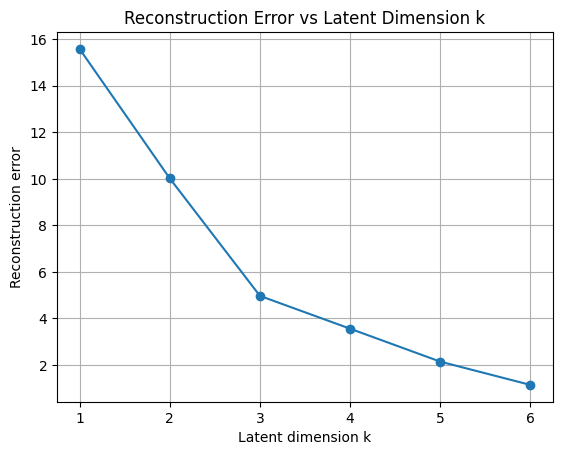

[np.float64(15.581167324031851),
 np.float64(10.019634011667524),
 np.float64(4.970697171698822),
 np.float64(3.560774536256893),
 np.float64(2.1454798279001044),
 np.float64(1.145479827900103)]

In [93]:
k_values = [1, 2, 3, 4, 5, 6]
rmr_plot(X,k_values)

Which value of k would you choose
for this data and why?

k=3, The reconstruction error decreases significantly when increasing from k=1 to k=3 and then further increases in k lead to smaller improvements.
This indicates diminishing returns, making it a good trade-off between reconstruction quality and model complexity.



1.4

In [94]:

def add_noise(X, p=0.1, seed=None):

    if seed is not None:
        np.random.seed(seed)

    # Generate a mask indicating which entries to flip
    flip_mask = np.random.rand(*X.shape) < p

    # Flip entries: 0 -> 1 and 1 -> 0
    X_noisy = X.copy()
    X_noisy[flip_mask] = 1 - X_noisy[flip_mask]

    return X_noisy


In [95]:
X_noisy = add_noise(X, p=0.1, seed=42)

In [96]:
X_noisy

array([[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1],
       [1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0],
       [0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0],
       [0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1],
       [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1]])

In [97]:
X

array([[0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0],
       [1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
       [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0],
       [0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1],
       [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]])

In [98]:
k=3
C_org,P_org,error_org=rmr_factorization(X,k, num_iters=50)
C_noisy,P_noisy,error_noisy=rmr_factorization(X_noisy,k, num_iters=50)

print(f"X noisy Error, X Error: {error_noisy}: {error_org}")

X noisy Error, X Error: 8.656999585641248: 4.970697171698822


In [80]:
import numpy as np
import matplotlib.pyplot as plt

def heatmap_matrix(X, title="Heatmap"):
    plt.figure(figsize=(6, 4))
    plt.imshow(X, aspect='auto')
    plt.colorbar(label="Value")
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [99]:
X_hat= C_org @ P_org.T
X_hat_noisy= C_noisy @ P_noisy.T

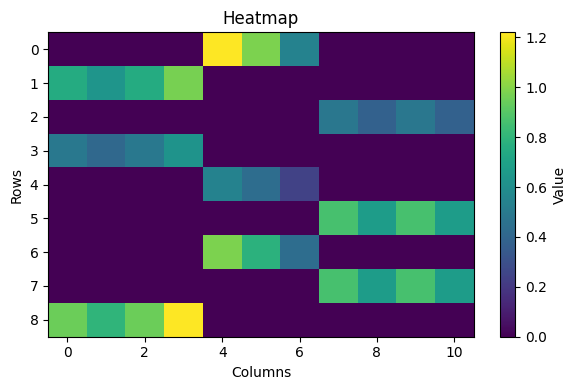

In [100]:
heatmap_matrix(X_hat)

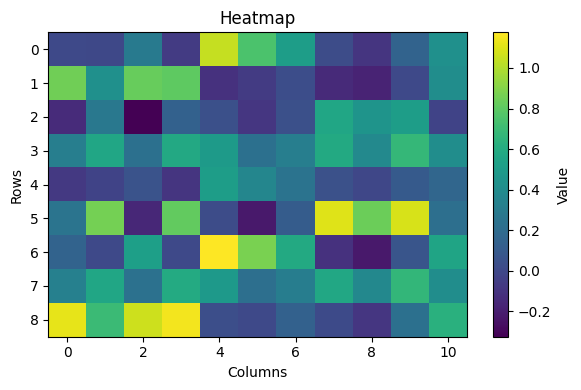

In [102]:
heatmap_matrix(X_hat_noisy)

Adding noise reduces the visual clarity of the latent user, movie blocks by introducing random fluctuations both within and outside the original clusters. While the overall block structure remains partially identifiable, the boundaries between clusters become less distinct, indicating that noise degrades, but does not completely eliminate the underlying latent structure.